# Análisis datos de laboratorio

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

## 4 de Mayo

Datos iniciales

In [23]:
h_total = 38e-2 # cm
h_libre = 9e-2 # cm
h_final_con_serpentin = 6.6e-2 # cm
d_balde = 29e-2 # cm, diámetro del balde
d_tuberia_cobre = 12.7e-3 # m, diámetro exterior de la tubería de cobre
espesor_tuberia_cobre = 0.6e-3 # m, espesor de la tubería de cobre

Volumen_agua = (h_total - h_libre) * np.pi * ((d_balde / 2) ** 2)# Volumen de agua en el tanque (m³)
Volumen_serpentin = ((h_total - h_final_con_serpentin) * np.pi * ((d_balde / 2) ** 2))  - Volumen_agua # Volumen de agua en el serpentin (m³)
largo_serpentin = Volumen_serpentin / (np.pi * ((d_tuberia_cobre / 2) ** 2)) # Largo del serpentin (m)
area_superficial_serpentin = np.pi * d_tuberia_cobre * largo_serpentin

print(f"Volumen de agua en el tanque: {Volumen_agua*1e3:.4f} L")
print(f'Diámetro de la tubería de cobre: {d_tuberia_cobre*1e3:.4f} mm')
print(f"Volumen del serpentin: {Volumen_serpentin*1e3:.4f} L")
print(f"Largo del serpentin: {largo_serpentin:.4f} m")
print(f'Área superficial del serpentin: {area_superficial_serpentin:.4f} m^2')

Volumen de agua en el tanque: 19.1551 L
Diámetro de la tubería de cobre: 12.7000 mm
Volumen del serpentin: 1.5852 L
Largo del serpentin: 12.5141 m
Área superficial del serpentin: 0.4993 m^2


Gráficos de la evolución de la temperatura en función del tiempo

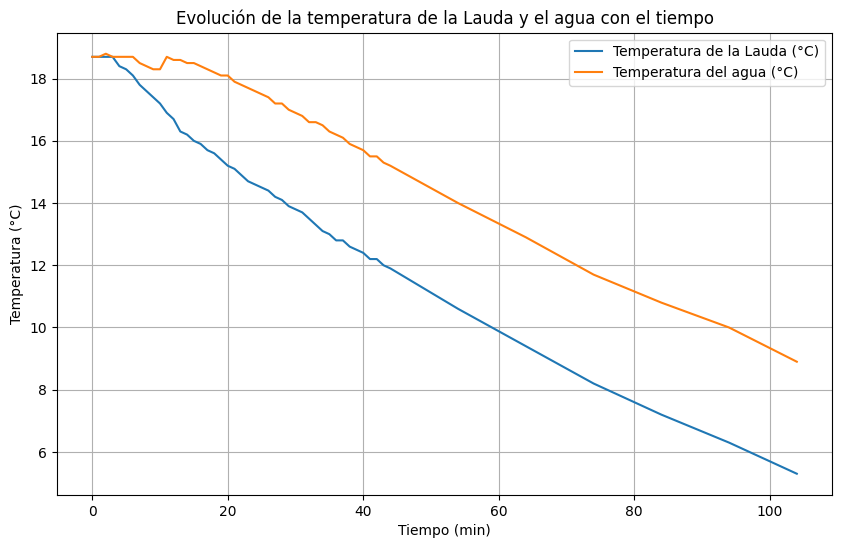

In [24]:
with open('datos_experimentales/info_lauda_4_mayo.csv', 'r') as f:
    data = f.readlines()

time_array = np.array([])
lauda_temperature_array = np.array([])
water_temperature_array = np.array([])

for line in data[1:]:
    cleaned_data = line.strip().split(';')
    time_array = np.append(time_array, float(cleaned_data[1]) * 60) # Tiempo en segundos
    lauda_temperature_array = np.append(lauda_temperature_array, float(cleaned_data[3].replace(',', '.'))) # Temperatura de la Lauda en °C
    water_temperature_array = np.append(water_temperature_array, float(cleaned_data[4].replace(',', '.'))) # Temperatura del agua en °C

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(time_array / 60, lauda_temperature_array, label='Temperatura de la Lauda (°C)')
plt.plot(time_array / 60, water_temperature_array, label='Temperatura del agua (°C)')
plt.xlabel('Tiempo (min)')
plt.ylabel('Temperatura (°C)')
plt.title('Evolución de la temperatura de la Lauda y el agua con el tiempo')
plt.legend()
plt.grid()
plt.show()  

Calculamos el $\dot{Q}_{agua}$ y lo comparamos con el $\dot{Q}_{max}$. **OJO QUE PARA CALCULAR LA EFECTIVIDAD DEL INTERCAMBIADOR DE CALOR, DEBEMOS CORREGIR EL BALANCE DE ENERGÍA USANDO LA CONVECCIÓN NATURAL DEL AGUA CON EL AMBIENTE**

Cálculo de la convección natural:

In [25]:
def Grashof(beta, T_inf, T_s, L_c, nu):
        return (9.81 * beta * (T_inf - T_s) * (L_c**3)) / (nu**2)

def conveccion_natural_placa_horizontal(Gr, Pr, k, L_c):
        Ra = Pr * Gr

        if 1e5 <= Ra <=1e11:
                Nu = 0.27 * (Ra ** 0.25)

                h = Nu * k / L_c

                return h
        
        else:
                return 0

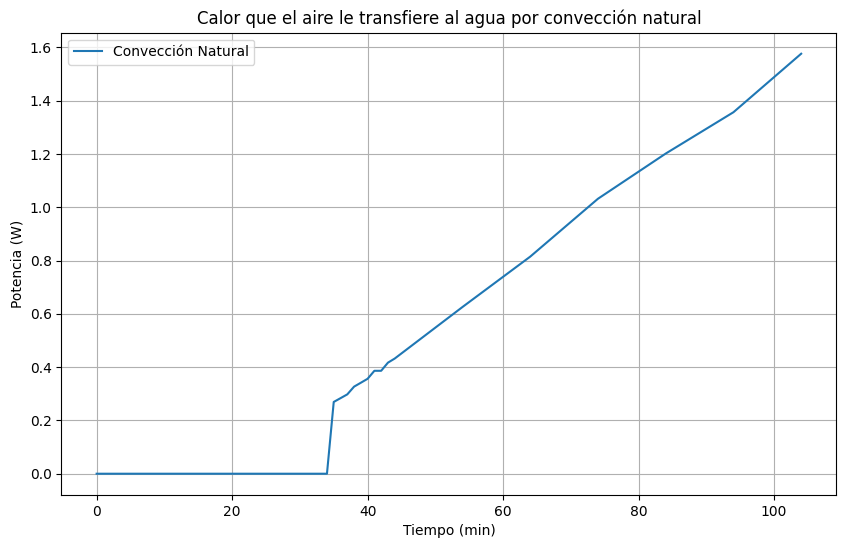

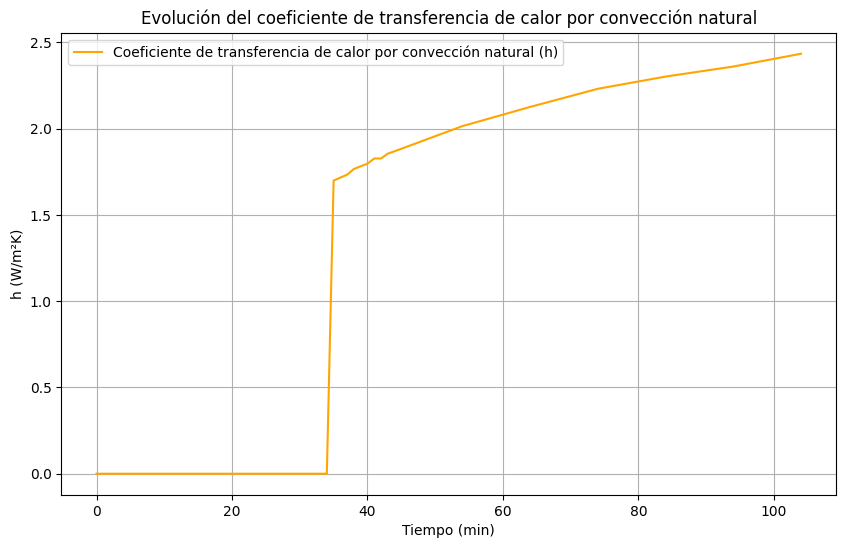

In [26]:
T_air = water_temperature_array[0]
g = 9.81
Area_superficial_balde = np.pi * (d_balde ** 2) / 4
perimetro_balde = np.pi * d_balde
L_c = Area_superficial_balde / perimetro_balde
Q_conv_natural_array = []
h_conv_natural_array = []

for T_Celsius in water_temperature_array:
    T = T_Celsius + 273.15
    rho_air = CP.PropsSI('D', 'T', T, 'P', 101325, 'Air') 
    k_air = CP.PropsSI('L', 'T', T, 'P', 101325, 'Air') 
    beta_air = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', T, 'P', 101325, 'Air')
    cp_air = CP.PropsSI('C', 'T', T, 'P', 101325, 'Air')
    mu_air = CP.PropsSI('V', 'T', T, 'P', 101325, 'Air')
    nu_air = mu_air / rho_air
    Pr = cp_air * mu_air / k_air

    Gr = Grashof(beta_air, T_air, T_Celsius, L_c, nu_air)
    h_conv_natural = conveccion_natural_placa_horizontal(Gr, Pr, k_air, L_c)
    
    if h_conv_natural != 0:
        h_conv_natural_array.append(h_conv_natural)
        Q_conv_natural = np.abs(h_conv_natural * Area_superficial_balde * (T_air - T_Celsius))
        Q_conv_natural_array.append(Q_conv_natural)
    else:
        Q_conv_natural_array.append(0)
        h_conv_natural_array.append(0)


# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(time_array / 60, Q_conv_natural_array, label='Convección Natural')
plt.xlabel('Tiempo (min)')
plt.ylabel('Potencia (W)')
plt.title('Calor que el aire le transfiere al agua por convección natural')
plt.legend()
plt.grid()
plt.show()  

# Plot the h_conv_natural_array
plt.figure(figsize=(10, 6))
plt.plot(time_array / 60, h_conv_natural_array, label='Coeficiente de transferencia de calor por convección natural (h)', color='orange')
plt.xlabel('Tiempo (min)')
plt.ylabel('h (W/m²K)')
plt.title('Evolución del coeficiente de transferencia de calor por convección natural')
plt.legend()
plt.grid()
plt.show()


/var/folders/tn/dyvt76z15n5_mr7pf5dg6w540000gn/T/ipykernel_6681/3005282590.py:18: RuntimeWarning: divide by zero encountered in divide
  efectividad_array = Q_water / Q_max # Efectividad del intercambiador de calor
/var/folders/tn/dyvt76z15n5_mr7pf5dg6w540000gn/T/ipykernel_6681/3005282590.py:18: RuntimeWarning: invalid value encountered in divide
  efectividad_array = Q_water / Q_max # Efectividad del intercambiador de calor


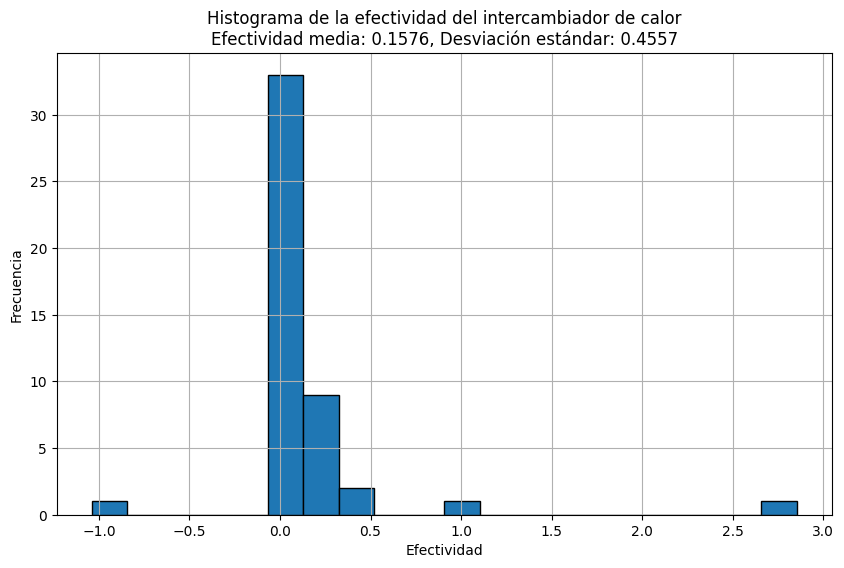

In [27]:
water_tank_density = CP.PropsSI('D', 'T', water_temperature_array[0] + 273.15, 'P', 101325, 'Water') # Densidad del agua a 20°C (kg/m³)
cp_water_tank = CP.PropsSI('C', 'T', water_temperature_array[0] + 273.15, 'P', 101325, 'Water') # Capacidad calorífica del agua a 20°C (J/kg·K)

water_mass = water_tank_density * Volumen_agua # Masa de agua en el tanque (kg)

# Calculamos el calor promeido que recibe el agua para cada instante de tiempo
Q_water = - (water_mass * cp_water_tank * np.diff(water_temperature_array) / np.diff(time_array)) # Potencia térmica recibida por el agua (W)

# Calculamos el calor máximo que entrega el intercambiador de calor
caudal_etanol = 15 * 0.001 / 60 # Caudal del etanol (15 L/min convertido a m³/s)
rho_etanol = CP.PropsSI('D', 'T', np.mean(lauda_temperature_array) + 273.15, 'P', 101325, 'Ethanol') # Densidad del etanol a la temperatura promedio (kg/m³)
cp_etanol = CP.PropsSI('C', 'T', np.mean(lauda_temperature_array) + 273.15, 'P', 101325, 'Ethanol') # Capacidad calorífica del etanol a la temperatura promedio (J/kg·K)
m_etanol = rho_etanol * caudal_etanol # Masa de etanol que fluye por segundo (kg/s)

delta_T_in = water_temperature_array[:-1] - lauda_temperature_array[:-1] # Diferencia de temperatura de entrada (K)
Q_max = m_etanol * cp_etanol * delta_T_in # Potencia térmica máxima entregada por el intercambiador de calor (W)

efectividad_array = Q_water / Q_max # Efectividad del intercambiador de calor

# Creamos un filtro que solo deja los números "finitos"
efectividad_limpia = efectividad_array[np.isfinite(efectividad_array)]

efectividad_media = np.mean(efectividad_limpia)
desviacion_estandar_efectividad = np.std(efectividad_limpia)

# Hacemos un histograma de la efectividad
plt.figure(figsize=(10, 6))
plt.hist(efectividad_limpia, bins=20, edgecolor='black')
plt.xlabel('Efectividad')
plt.ylabel('Frecuencia')
plt.title(f'Histograma de la efectividad del intercambiador de calor\nEfectividad media: {efectividad_media:.4f}, Desviación estándar: {desviacion_estandar_efectividad:.4f}')
plt.grid()  
plt.show()  

Graficamos el $\dot{q}_{agua}$ en función del tiempo y calculamos el valor medio

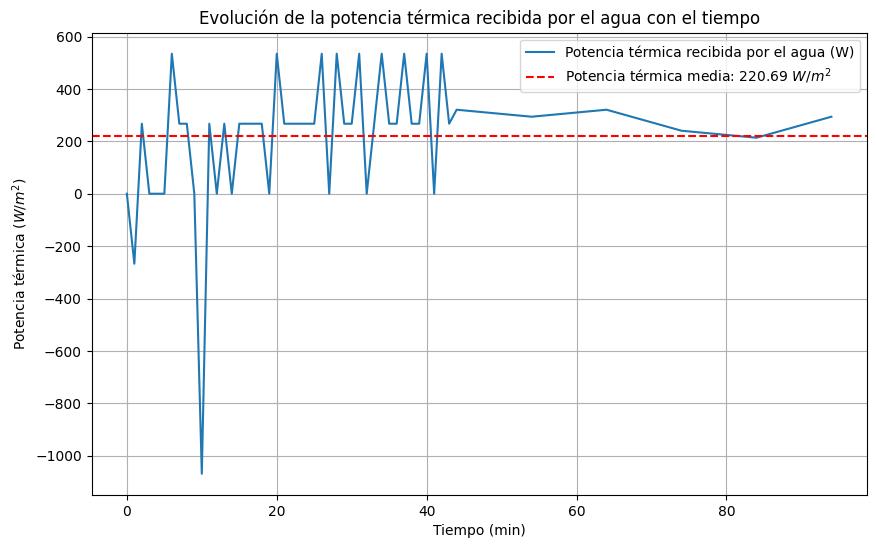

In [28]:
# Calculamos el calor promeido que recibe el agua para cada instante de tiempo
Q_water = - (water_mass * cp_water_tank * np.diff(water_temperature_array) / np.diff(time_array)) # Potencia térmica recibida por el agua (W)
q_water = Q_water / area_superficial_serpentin
mean_q_dot_water = np.mean(q_water)
std_q_dot_water = np.std(q_water)
# Plot de la potencia térmica recibida por el agua en función del tiempo
plt.figure(figsize=(10, 6))
plt.plot(time_array[:-1] / 60, q_water, label=r'Potencia térmica recibida por el agua (W)')
plt.axhline(mean_q_dot_water, color='r', linestyle='--', label=rf'Potencia térmica media: {mean_q_dot_water:.2f} $W/m^2$')
plt.xlabel('Tiempo (min)')
plt.ylabel(r'Potencia térmica ($W/m^2$)')
plt.title('Evolución de la potencia térmica recibida por el agua con el tiempo')
plt.legend()
plt.grid()  
plt.show()

## 6 de Mayo

Definimos los datos iniciales

In [29]:
h_total = 35.8e-2 # cm
h_libre = 9e-2 # cm
h_final_con_serpentin = 6.6e-2 # cm
d_balde = 29e-2 # cm, diámetro del balde
d_tuberia_cobre = 12.7e-3 # m, diámetro exterior de la tubería de cobre
espesor_tuberia_cobre = 0.6e-3 # m, espesor de la tubería de cobre

Volumen_agua = (h_total - h_libre) * np.pi * ((d_balde / 2) ** 2)# Volumen de agua en el tanque (m³)
Volumen_serpentin = ((h_total - h_final_con_serpentin) * np.pi * ((d_balde / 2) ** 2))  - Volumen_agua # Volumen de agua en el serpentin (m³)
largo_serpentin = Volumen_serpentin / (np.pi * ((d_tuberia_cobre / 2) ** 2)) # Largo del serpentin (m)
area_superficial_serpentin = np.pi * d_tuberia_cobre * largo_serpentin

print(f"Volumen de agua en el tanque: {Volumen_agua*1e3:.4f} L")
print(f'Diámetro de la tubería de cobre: {d_tuberia_cobre*1e3:.4f} mm')
print(f"Volumen del serpentin: {Volumen_serpentin*1e3:.4f} L")
print(f"Largo del serpentin: {largo_serpentin:.4f} m")
print(f'Área superficial del serpentin: {area_superficial_serpentin:.4f} m^2')

Volumen de agua en el tanque: 17.7019 L
Diámetro de la tubería de cobre: 12.7000 mm
Volumen del serpentin: 1.5852 L
Largo del serpentin: 12.5141 m
Área superficial del serpentin: 0.4993 m^2


Abrimos los datos y graficamos la temperatura en función del tiempo

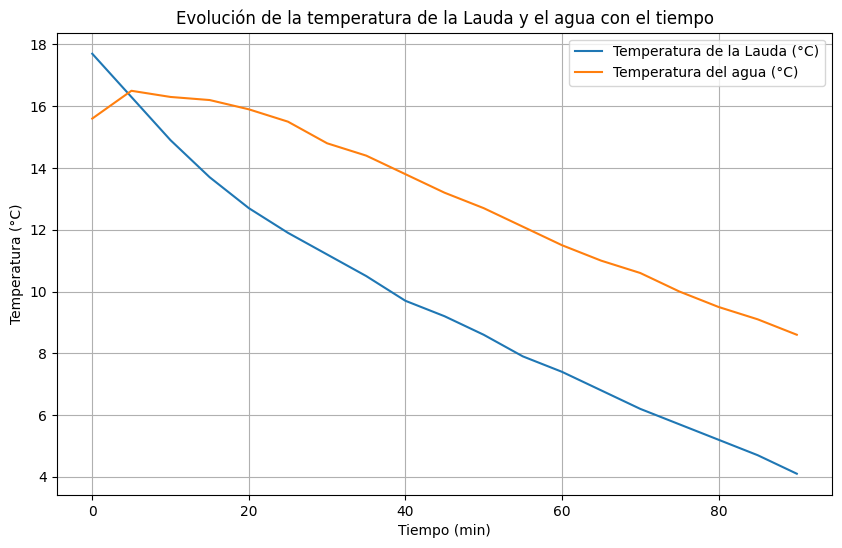

In [30]:
with open('datos_experimentales/datos_6_de_mayo.csv', 'r') as f:
    data = f.readlines()

time_array = np.array([])
lauda_temperature_array = np.array([])
water_temperature_array = np.array([])

for line in data[1:]:
    cleaned_data = line.strip().split(';')
    time_array = np.append(time_array, float(cleaned_data[1]) * 60) # Tiempo en segundos
    lauda_temperature_array = np.append(lauda_temperature_array, float(cleaned_data[3].replace(',', '.'))) # Temperatura de la Lauda en °C
    water_temperature_array = np.append(water_temperature_array, float(cleaned_data[4].replace(',', '.'))) # Temperatura del agua en °C

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(time_array / 60, lauda_temperature_array, label='Temperatura de la Lauda (°C)')
plt.plot(time_array / 60, water_temperature_array, label='Temperatura del agua (°C)')
plt.xlabel('Tiempo (min)')
plt.ylabel('Temperatura (°C)')
plt.title('Evolución de la temperatura de la Lauda y el agua con el tiempo')
plt.legend()
plt.grid()
plt.show()  

Calculamos el $\dot{Q}_{agua}$ y lo comparamos con el $\dot{Q}_{max}$. **OJO QUE PARA CALCULAR LA EFECTIVIDAD DEL INTERCAMBIADOR DE CALOR, DEBEMOS CORREGIR EL BALANCE DE ENERGÍA USANDO LA CONVECCIÓN NATURAL DEL AGUA CON EL AMBIENTE**

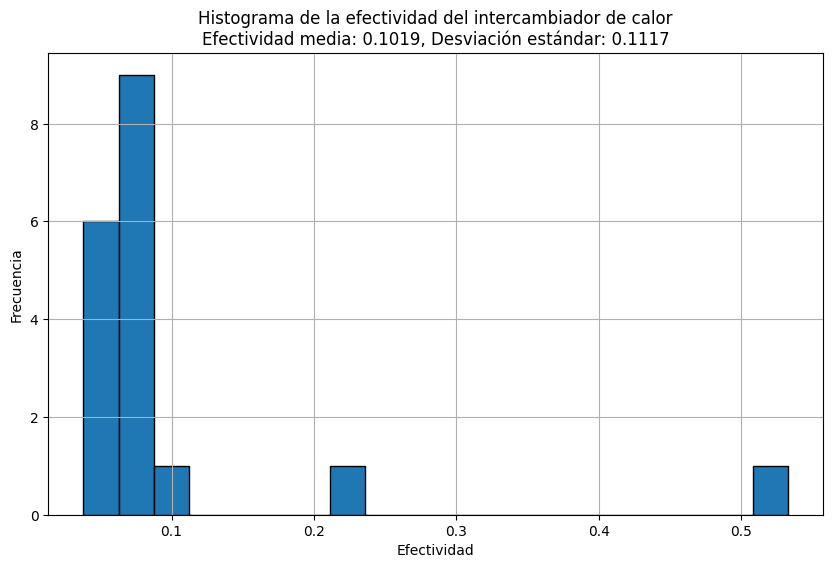

In [31]:
water_tank_density = CP.PropsSI('D', 'T', water_temperature_array[0] + 273.15, 'P', 101325, 'Water') # Densidad del agua a 20°C (kg/m³)
cp_water_tank = CP.PropsSI('C', 'T', water_temperature_array[0] + 273.15, 'P', 101325, 'Water') # Capacidad calorífica del agua a 20°C (J/kg·K)

water_mass = water_tank_density * Volumen_agua # Masa de agua en el tanque (kg)

# Calculamos el calor promeido que recibe el agua para cada instante de tiempo
Q_water = - (water_mass * cp_water_tank * np.diff(water_temperature_array) / np.diff(time_array)) # Potencia térmica recibida por el agua (W)

# Calculamos el calor máximo que entrega el intercambiador de calor
caudal_etanol = 15 * 0.001 / 60 # Caudal del etanol (15 L/min convertido a m³/s)
rho_etanol = CP.PropsSI('D', 'T', np.mean(lauda_temperature_array) + 273.15, 'P', 101325, 'Ethanol') # Densidad del etanol a la temperatura promedio (kg/m³)
cp_etanol = CP.PropsSI('C', 'T', np.mean(lauda_temperature_array) + 273.15, 'P', 101325, 'Ethanol') # Capacidad calorífica del etanol a la temperatura promedio (J/kg·K)
m_etanol = rho_etanol * caudal_etanol # Masa de etanol que fluye por segundo (kg/s)

delta_T_in = water_temperature_array[:-1] - lauda_temperature_array[:-1] # Diferencia de temperatura de entrada (K)
Q_max = m_etanol * cp_etanol * delta_T_in # Potencia térmica máxima entregada por el intercambiador de calor (W)

efectividad_array = Q_water / Q_max # Efectividad del intercambiador de calor

# Creamos un filtro que solo deja los números "finitos"
efectividad_limpia = efectividad_array[np.isfinite(efectividad_array)]

efectividad_media = np.mean(efectividad_limpia)
desviacion_estandar_efectividad = np.std(efectividad_limpia)

# Hacemos un histograma de la efectividad
plt.figure(figsize=(10, 6))
plt.hist(efectividad_limpia, bins=20, edgecolor='black')
plt.xlabel('Efectividad')
plt.ylabel('Frecuencia')
plt.title(f'Histograma de la efectividad del intercambiador de calor\nEfectividad media: {efectividad_media:.4f}, Desviación estándar: {desviacion_estandar_efectividad:.4f}')
plt.grid()  
plt.show()  

Graficamos el $\dot{q}_{agua}$ en función del tiempo y calculamos el valor medio

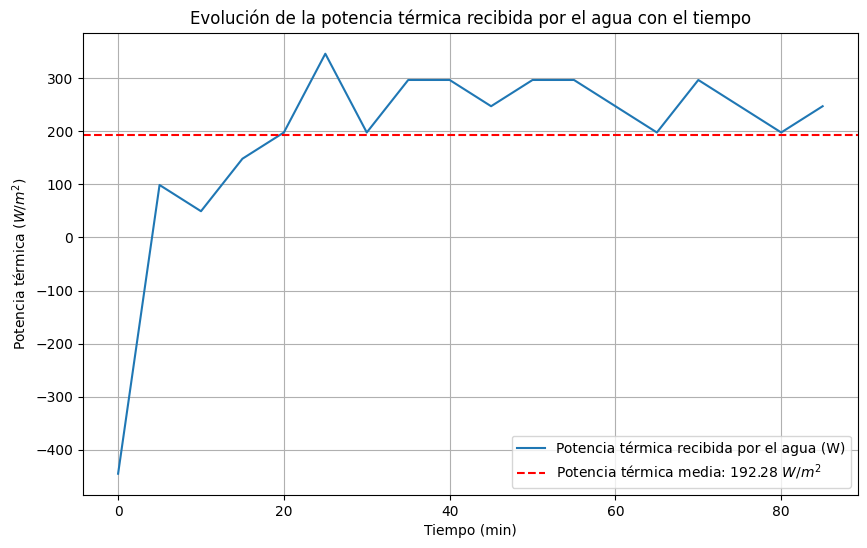

In [32]:
# Calculamos el calor promeido que recibe el agua para cada instante de tiempo
Q_water = - (water_mass * cp_water_tank * np.diff(water_temperature_array) / np.diff(time_array)) # Potencia térmica recibida por el agua (W)
q_water = Q_water / area_superficial_serpentin
mean_q_dot_water = np.mean(q_water)
std_q_dot_water = np.std(q_water)
# Plot de la potencia térmica recibida por el agua en función del tiempo
plt.figure(figsize=(10, 6))
plt.plot(time_array[:-1] / 60, q_water, label=r'Potencia térmica recibida por el agua (W)')
plt.axhline(mean_q_dot_water, color='r', linestyle='--', label=rf'Potencia térmica media: {mean_q_dot_water:.2f} $W/m^2$')
plt.xlabel('Tiempo (min)')
plt.ylabel(r'Potencia térmica ($W/m^2$)')
plt.title('Evolución de la potencia térmica recibida por el agua con el tiempo')
plt.legend()
plt.grid()  
plt.show()